# Chapter 9 — Digital Filter Design (1-D & 2-D)

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch09_filter_design.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch09_filter_design.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch09_filter_design.ipynb)

> **Motivating question.** How do we keep the spindles and drop the hum — and why is despiking an image the same trick as despiking an ECG?

## What this notebook demonstrates

- LTI systems and convolution (the impulse response slid along)
- IIR (Butterworth) design as second-order sections for stability
- Zero-phase filtfilt vs a real-time causal filter
- Linear vs non-linear: median/Savitzky-Golay beat the mean on outliers
- 2-D spatial filtering and the Pan–Tompkins QRS detector

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from scipy import signal as sig
from scipy import ndimage

CH = 9

## 9.1  convolution

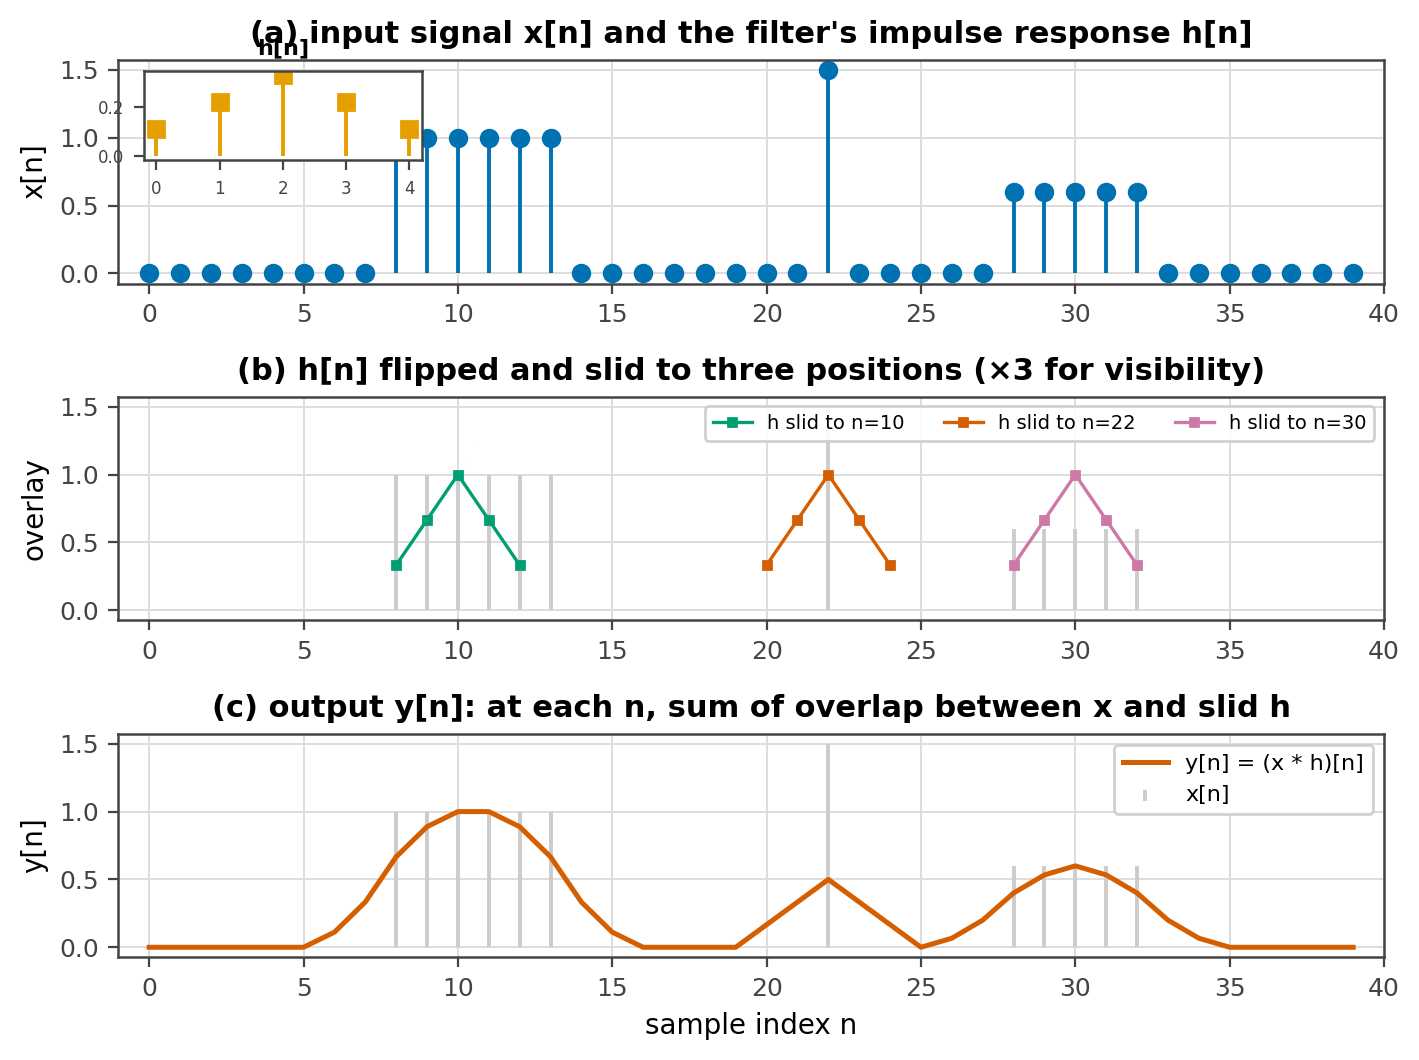

In [3]:
# A short signal: two rectangular bumps + a spike
n = np.arange(40)
x = np.zeros(40)
x[8:14] = 1.0
x[22] = 1.5          # an impulse-like spike
x[28:33] = 0.6
# A short smoothing kernel (normalized triangular impulse response)
h = np.array([1, 2, 3, 2, 1], dtype=float)
h /= h.sum()
y = np.convolve(x, h, mode="same")

fig, ax = bs.newfig(w=7.2, h=5.4, nrows=3, ncols=1)

# (a) the signal and the kernel
ax[0].stem(n, x, linefmt=bs.C["blue"], markerfmt="o", basefmt=" ")
ax[0].set_title("(a) input signal x[n] and the filter's impulse response h[n]")
ax[0].set_ylabel("x[n]")
# inset kernel drawn at the left
kx = np.arange(len(h))
axins = ax[0].inset_axes([0.02, 0.55, 0.22, 0.4])
axins.stem(kx, h, linefmt=bs.C["orange"], markerfmt="s", basefmt=" ")
axins.set_title("h[n]", fontsize=8)
axins.tick_params(labelsize=6)
axins.grid(False)

# (b) the kernel flipped-and-slid to three positions, overlaying x
ax[1].stem(n, x, linefmt=bs.C["lightgrey"], markerfmt=" ", basefmt=" ")
for pos, col in zip([10, 22, 30], [bs.C["green"], bs.C["red"], bs.C["purple"]]):
    hx = pos + np.arange(len(h)) - len(h) // 2
    ax[1].plot(hx, h * 3 + 0.0, color=col, marker="s", ms=3, lw=1.2,
               label=f"h slid to n={pos}")
ax[1].set_title("(b) h[n] flipped and slid to three positions (×3 for visibility)")
ax[1].set_ylabel("overlay")
ax[1].legend(loc="upper right", ncol=3, fontsize=7)

# (c) the output = running weighted overlap
ax[2].stem(n, x, linefmt=bs.C["lightgrey"], markerfmt=" ", basefmt=" ",
           label="x[n]")
ax[2].plot(n, y, color=bs.C["red"], lw=1.8, label="y[n] = (x * h)[n]")
ax[2].set_title("(c) output y[n]: at each n, sum of overlap between x and slid h")
ax[2].set_ylabel("y[n]")
ax[2].set_xlabel("sample index n")
ax[2].legend(loc="upper right", fontsize=8)

for a in ax:
    a.set_xlim(-1, 40)
plt.tight_layout()
plt.show()

## 9.2  iir families

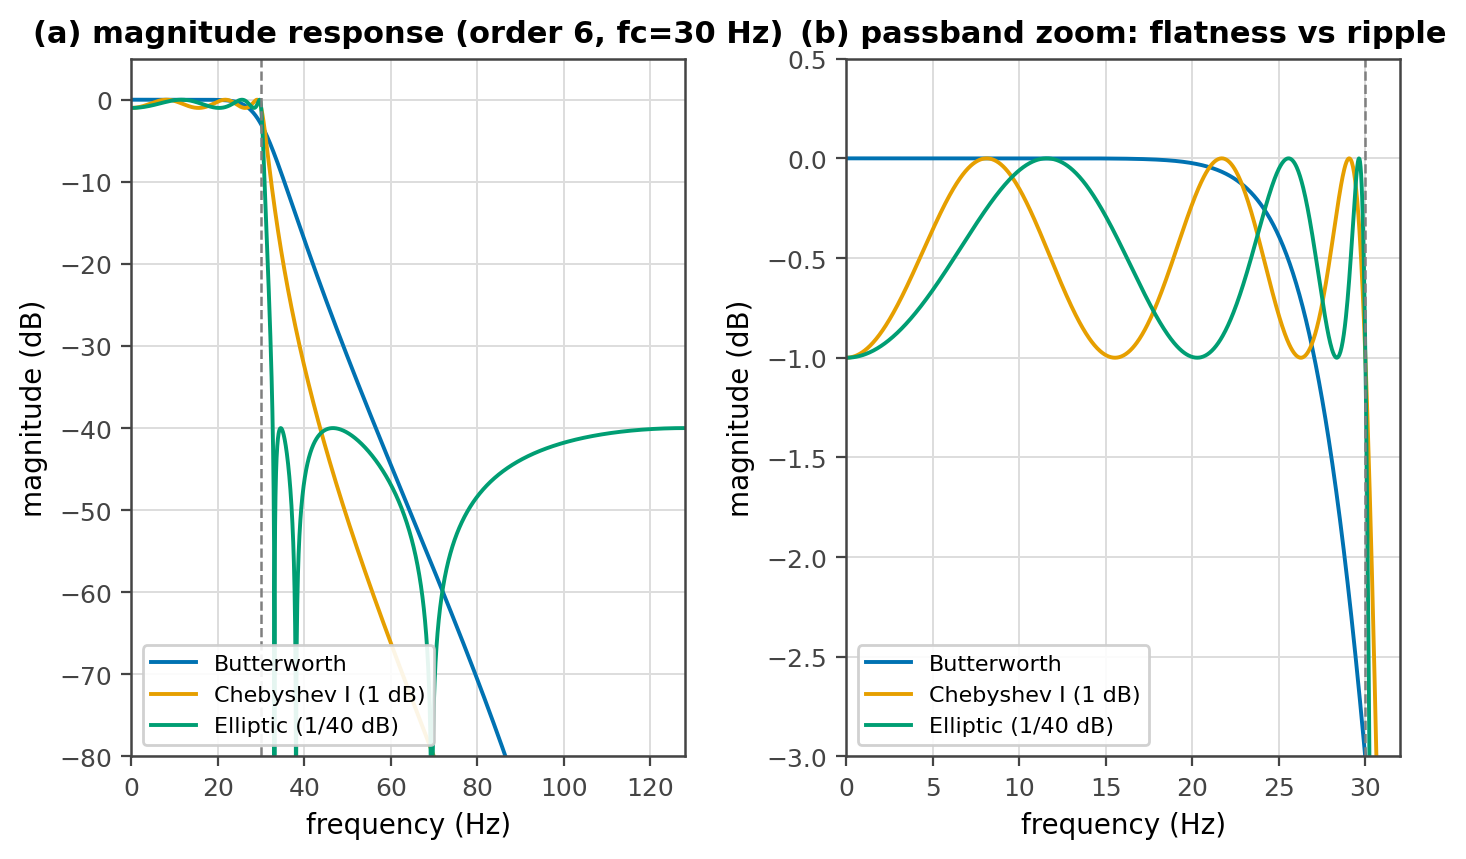

In [4]:
fs = 256.0
fc = 30.0          # cutoff Hz
order = 6
wn = fc / (fs / 2)

b_bw, a_bw = sig.butter(order, wn, btype="low")
b_c1, a_c1 = sig.cheby1(order, 1.0, wn, btype="low")     # 1 dB passband ripple
b_el, a_el = sig.ellip(order, 1.0, 40.0, wn, btype="low")  # 1 dB / 40 dB

fig, ax = bs.newfig(w=7.2, h=4.4, nrows=1, ncols=2)

for (b, a), name, col in [
    ((b_bw, a_bw), "Butterworth", bs.C["blue"]),
    ((b_c1, a_c1), "Chebyshev I (1 dB)", bs.C["orange"]),
    ((b_el, a_el), "Elliptic (1/40 dB)", bs.C["green"]),
]:
    w, hh = sig.freqz(b, a, worN=4096, fs=fs)
    mag = 20 * np.log10(np.abs(hh) + 1e-12)
    ax[0].plot(w, mag, color=col, label=name)
    ax[1].plot(w, mag, color=col, label=name)

ax[0].axvline(fc, color=bs.C["grey"], ls="--", lw=0.9)
ax[0].set_title(f"(a) magnitude response (order {order}, fc={fc:.0f} Hz)")
ax[0].set_xlabel("frequency (Hz)")
ax[0].set_ylabel("magnitude (dB)")
ax[0].set_ylim(-80, 5)
ax[0].set_xlim(0, fs / 2)
ax[0].legend(loc="lower left", fontsize=8)

# zoom on the passband to reveal ripple vs flatness
ax[1].axvline(fc, color=bs.C["grey"], ls="--", lw=0.9)
ax[1].set_title("(b) passband zoom: flatness vs ripple")
ax[1].set_xlabel("frequency (Hz)")
ax[1].set_ylabel("magnitude (dB)")
ax[1].set_ylim(-3, 0.5)
ax[1].set_xlim(0, fc + 2)
ax[1].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

## 9.3  outlier lesson

/var/folders/b8/tlcb8g7163zgtrljj8c2c9p80000gp/T/ipykernel_91302/3222441589.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


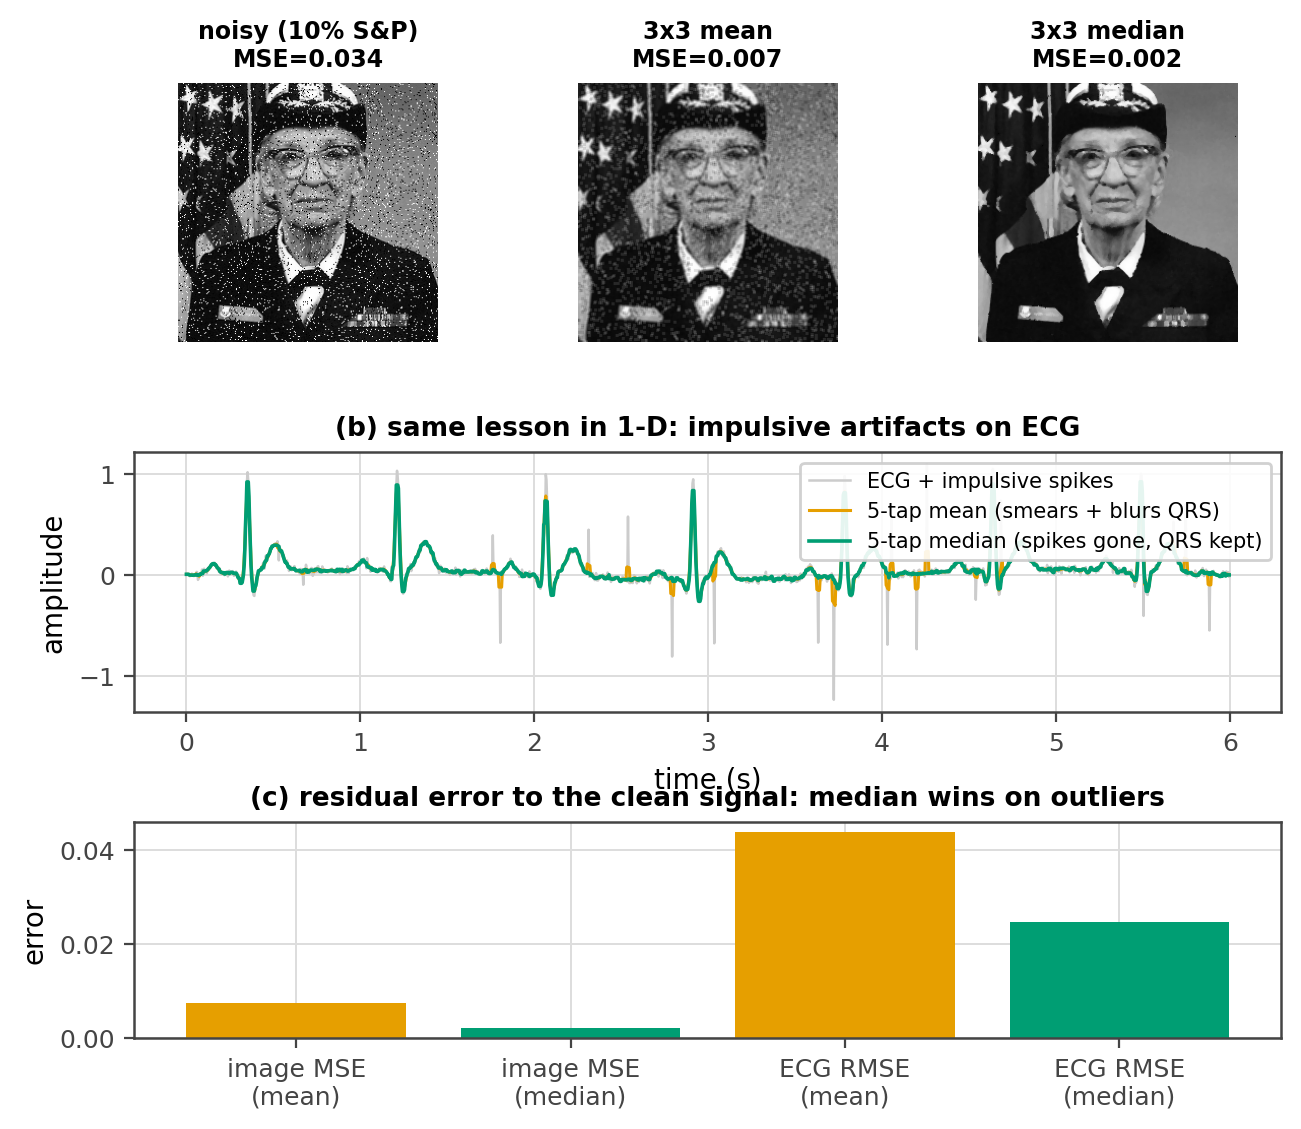

In [5]:
# --- image side: salt-and-pepper on a photographic test image ---
img = bio.test_photo(256)
noisy = bio.salt_pepper(img, amount=0.10)
mean3 = ndimage.uniform_filter(noisy, size=3)
med3 = ndimage.median_filter(noisy, size=3)

def mse(a, b):
    return np.mean((a - b) ** 2)

# --- signal side: impulsive spikes on ECG ---
t, x = bio.ecg(duration=6.0, fs=256, noise=0.02)
r = np.random.default_rng(21)
xs = x.copy()
spike_idx = r.integers(0, len(x), size=25)
xs[spike_idx] += r.uniform(-1.2, 1.2, size=25)      # electrode "pops"
x_med = sig.medfilt(xs, kernel_size=5)
x_mean = np.convolve(xs, np.ones(5) / 5, mode="same")

fig = bs.plt.figure(figsize=(7.4, 6.2))
gs = fig.add_gridspec(3, 3, height_ratios=[1.2, 1.2, 1.0], hspace=0.45,
                      wspace=0.15)

# row of images
for j, (im, ttl) in enumerate([
    (noisy, f"noisy (10% S&P)\nMSE={mse(noisy, img):.3f}"),
    (mean3, f"3x3 mean\nMSE={mse(mean3, img):.3f}"),
    (med3, f"3x3 median\nMSE={mse(med3, img):.3f}"),
]):
    a = fig.add_subplot(gs[0, j])
    a.imshow(im, cmap="gray", vmin=0, vmax=1)
    a.set_title(ttl, fontsize=8.5)
    a.axis("off")

a = fig.add_subplot(gs[1, :])
a.plot(t, xs, color=bs.C["lightgrey"], lw=0.9, label="ECG + impulsive spikes")
a.plot(t, x_mean, color=bs.C["orange"], lw=1.1, label="5-tap mean (smears + blurs QRS)")
a.plot(t, x_med, color=bs.C["green"], lw=1.3, label="5-tap median (spikes gone, QRS kept)")
a.set_title("(b) same lesson in 1-D: impulsive artifacts on ECG", fontsize=9.5)
a.set_ylabel("amplitude")
a.set_xlabel("time (s)")
a.legend(loc="upper right", fontsize=7.5, ncol=1)
a.grid(True)

# a tiny bar comparing residual error (image MSE vs ECG RMSE-to-clean)
a = fig.add_subplot(gs[2, :])
ecg_mean_rmse = np.sqrt(mse(x_mean, x))
ecg_med_rmse = np.sqrt(mse(x_med, x))
labels = ["image MSE\n(mean)", "image MSE\n(median)",
          "ECG RMSE\n(mean)", "ECG RMSE\n(median)"]
vals = [mse(mean3, img), mse(med3, img), ecg_mean_rmse, ecg_med_rmse]
cols = [bs.C["orange"], bs.C["green"], bs.C["orange"], bs.C["green"]]
a.bar(labels, vals, color=cols)
a.set_title("(c) residual error to the clean signal: median wins on outliers",
            fontsize=9.5)
a.set_ylabel("error")
a.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 9.4  2d linear

50 Hz attenuation -- band-pass stage: 23.18 dB | notch stage: 47.82 dB | total: 71.00 dB


/var/folders/b8/tlcb8g7163zgtrljj8c2c9p80000gp/T/ipykernel_91302/922870280.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


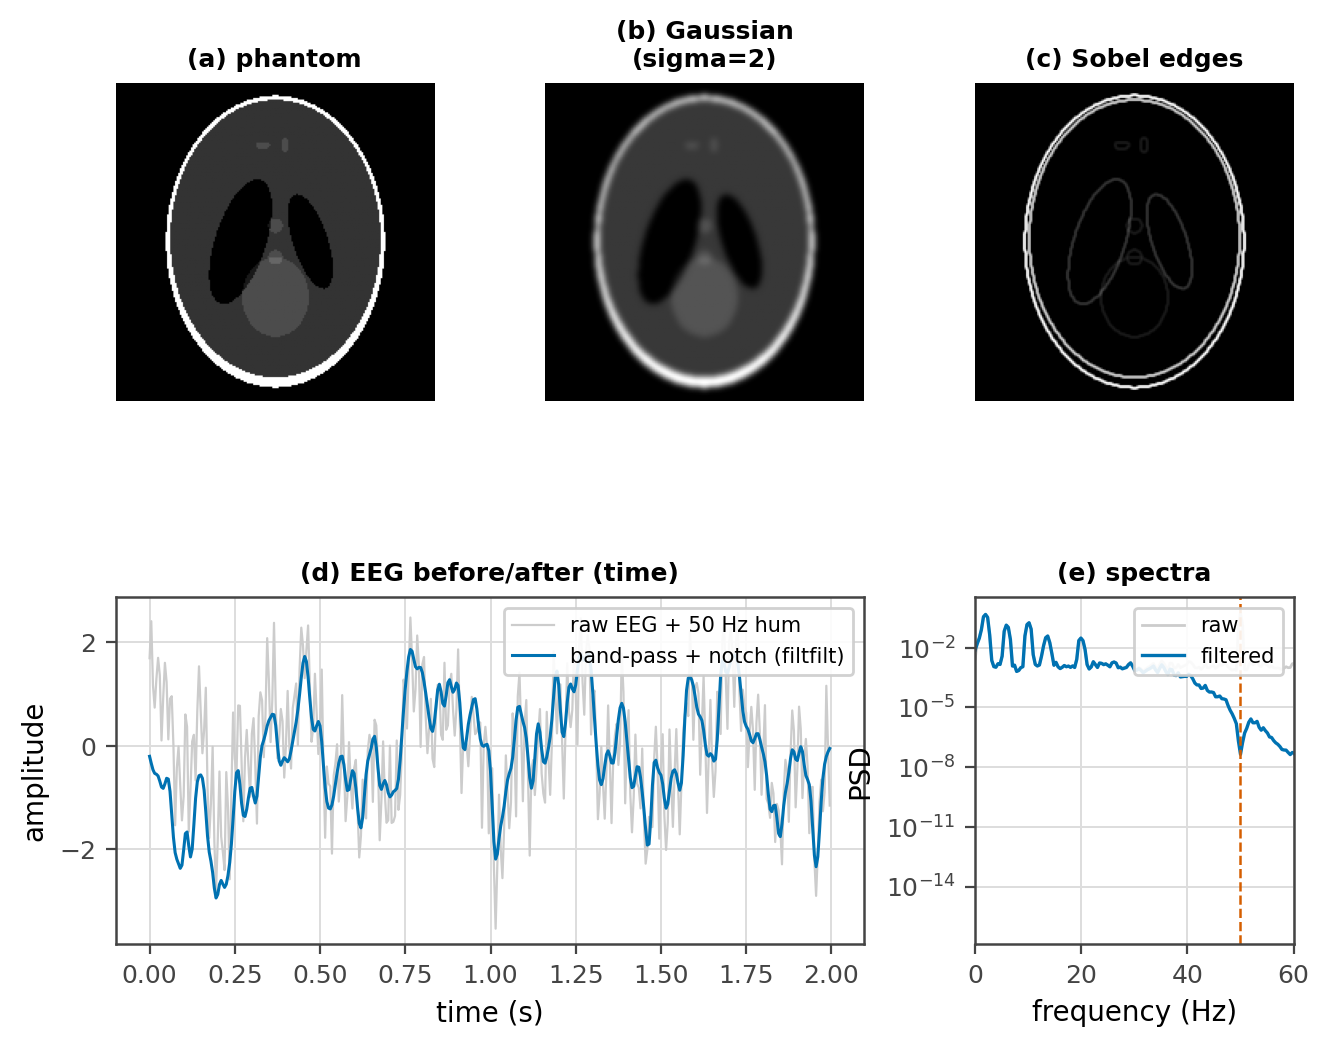

In [6]:
img = bio.head_phantom(size=200)
smooth = ndimage.gaussian_filter(img, sigma=2.0)
sx = ndimage.sobel(img, axis=0)
sy = ndimage.sobel(img, axis=1)
edges = np.hypot(sx, sy)
edges = edges / (edges.max() + 1e-12)

# EEG with added powerline hum.  fs=200 Hz keeps the 50 Hz line comfortably
# below Nyquist (100 Hz) so the notch is a genuine narrow band-stop, not a
# degenerate filter at the Nyquist edge.
fs = 200.0
t, x = bio.eeg(duration=20.0, fs=fs, stage="N2")
hum = bio.powerline(len(x), fs, f0=50.0, amp=0.8, harmonics=(1,))
xn = x + hum

# Sleep-EEG spec (single coherent design): 0.5 Hz high-pass (preserve delta)
# + ~40 Hz low-pass (reject muscle/instrumentation) + a narrow 50 Hz notch.
nyq = fs / 2
# Second-order sections: numerically robust for repeated deployment on
# fixed-point/embedded targets (Ch. 15), unlike a single high-order b/a.
sos_bp = sig.butter(4, [0.5 / nyq, 40 / nyq], btype="band", output="sos")
w0 = 50.0 / nyq
b_no, a_no = sig.iirnotch(w0, Q=30.0)
sos_no = sig.tf2sos(b_no, a_no)
y_bp = sig.sosfiltfilt(sos_bp, xn)
y = sig.sosfiltfilt(sos_no, y_bp)

f_raw, p_raw = sig.welch(xn, fs=fs, nperseg=512)
f_bp, p_bp = sig.welch(y_bp, fs=fs, nperseg=512)
f_flt, p_flt = sig.welch(y, fs=fs, nperseg=512)

atten_bp = 10 * np.log10(np.interp(50, f_raw, p_raw) / np.interp(50, f_bp, p_bp))
atten_notch = 10 * np.log10(np.interp(50, f_bp, p_bp) / np.interp(50, f_flt, p_flt))
atten_total = 10 * np.log10(np.interp(50, f_raw, p_raw) / np.interp(50, f_flt, p_flt))
print(f"50 Hz attenuation -- band-pass stage: {atten_bp:.2f} dB | "
      f"notch stage: {atten_notch:.2f} dB | total: {atten_total:.2f} dB")

fig = bs.plt.figure(figsize=(7.6, 5.8))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1.0], hspace=0.45,
                      wspace=0.35)

for j, (im, ttl) in enumerate([
    (img, "(a) phantom"),
    (smooth, "(b) Gaussian\n(sigma=2)"),
    (edges, "(c) Sobel edges"),
]):
    a = fig.add_subplot(gs[0, j])
    a.imshow(im, cmap="gray")
    a.set_title(ttl, fontsize=9)
    a.axis("off")

a = fig.add_subplot(gs[1, :2])
a.plot(t[:400], xn[:400], color=bs.C["lightgrey"], lw=0.8, label="raw EEG + 50 Hz hum")
a.plot(t[:400], y[:400], color=bs.C["blue"], lw=1.1, label="band-pass + notch (filtfilt)")
a.set_title("(d) EEG before/after (time)", fontsize=9)
a.set_xlabel("time (s)")
a.set_ylabel("amplitude")
a.legend(loc="upper right", fontsize=7.5)

a = fig.add_subplot(gs[1, 2])
a.semilogy(f_raw, p_raw, color=bs.C["lightgrey"], lw=1.0, label="raw")
a.semilogy(f_flt, p_flt, color=bs.C["blue"], lw=1.2, label="filtered")
a.axvline(50, color=bs.C["red"], ls="--", lw=0.9)
a.set_title("(e) spectra", fontsize=9)
a.set_xlabel("frequency (Hz)")
a.set_ylabel("PSD")
a.set_xlim(0, 60)
a.legend(loc="upper right", fontsize=7.5)
plt.tight_layout()
plt.show()

## 9.5  pan tompkins

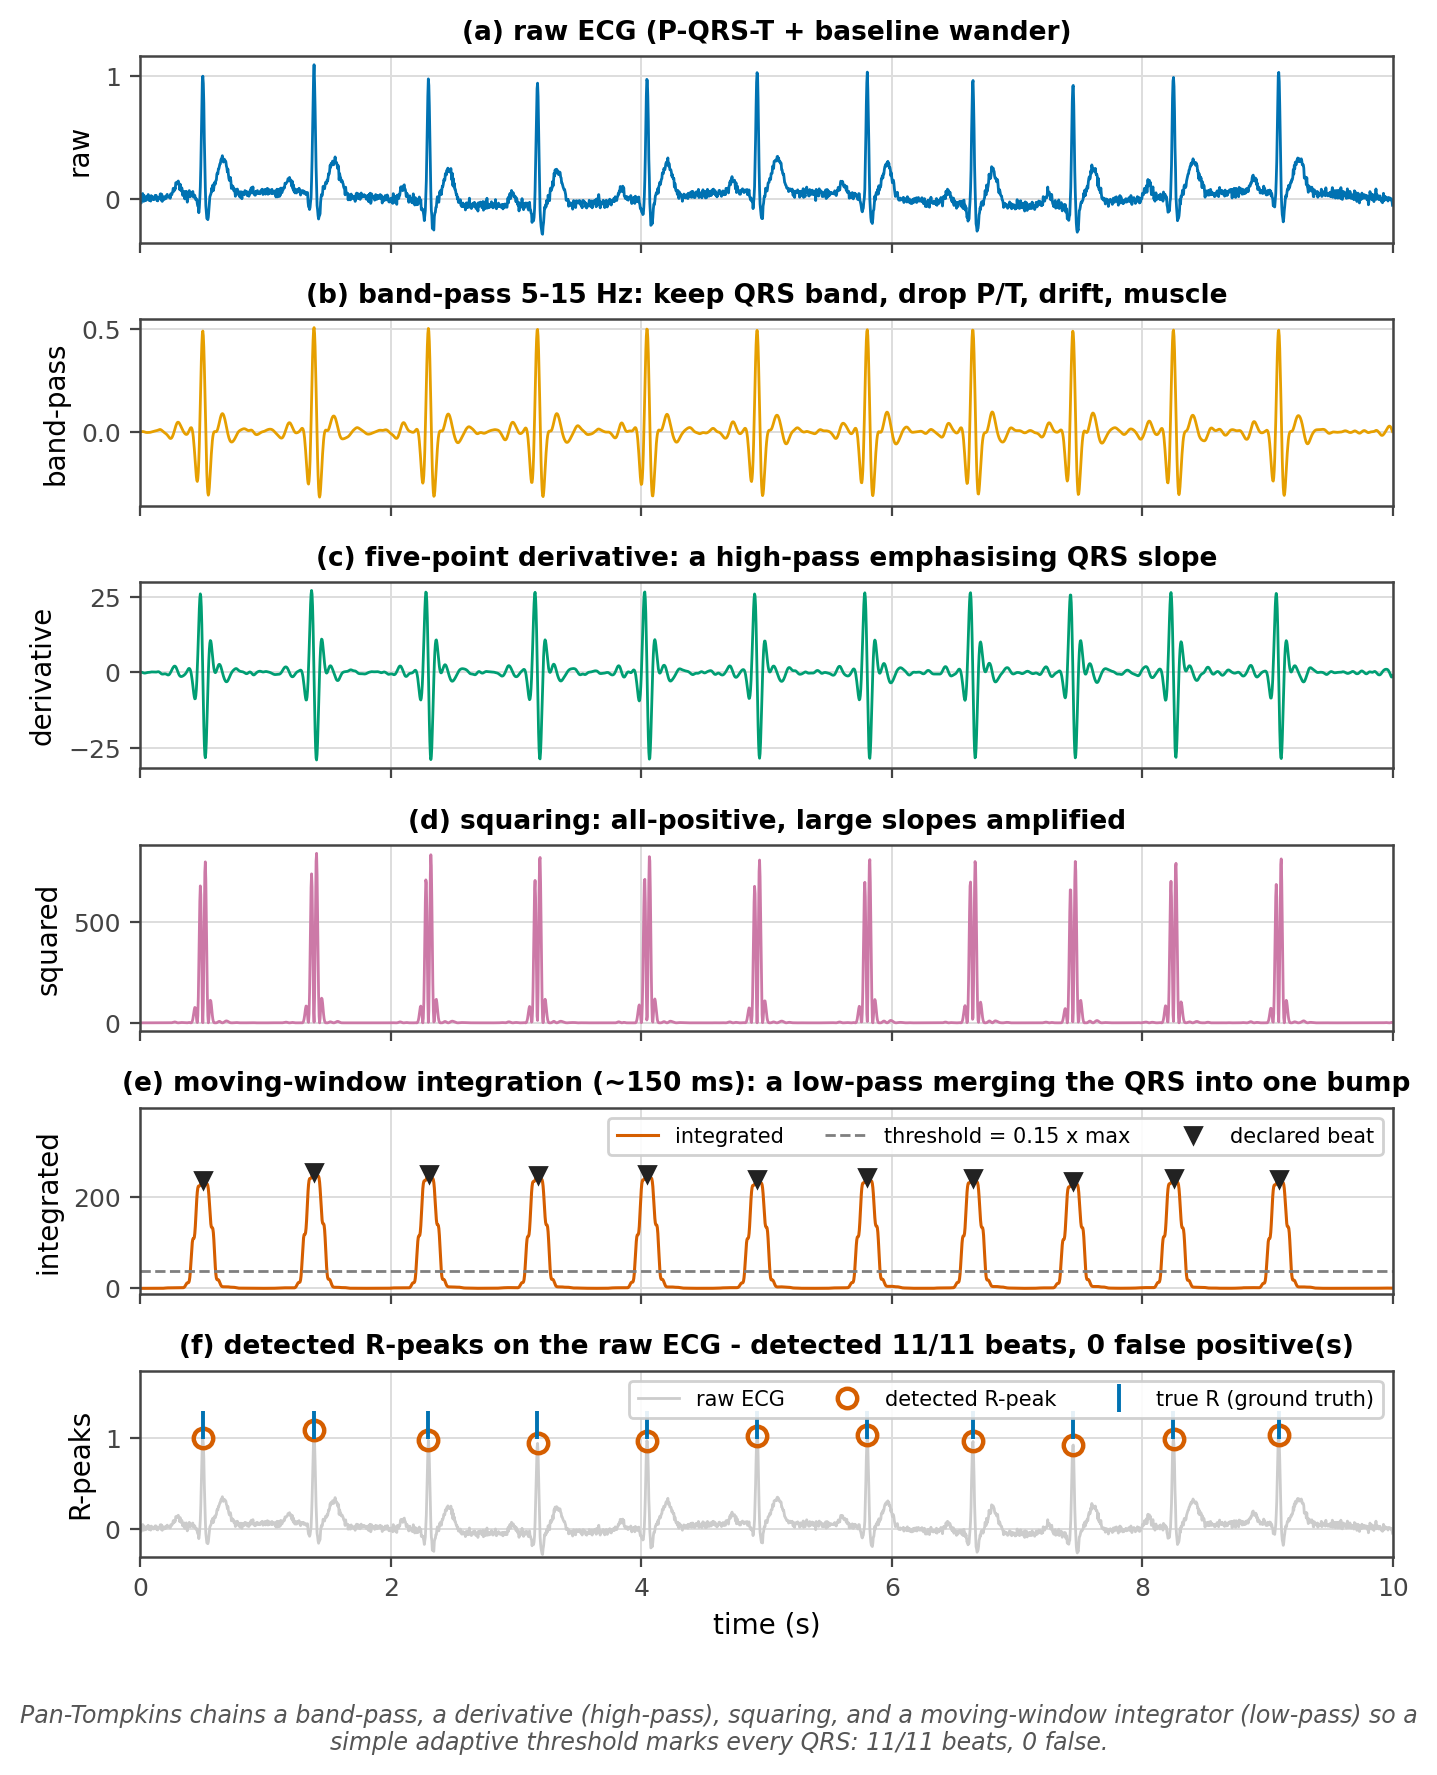

In [7]:
fs = 250.0
t, ecg, r_times = bio.ecg_hrv(duration=10, fs=fs, seed=21)
nyq = fs / 2.0

# (1) band-pass ~5-15 Hz (Butterworth, zero-phase) -> keep QRS energy band
b_bp, a_bp = sig.butter(2, [5 / nyq, 15 / nyq], btype="band")
bp = sig.filtfilt(b_bp, a_bp, ecg)

# (2) five-point derivative -> emphasise the steep QRS slope (a high-pass)
deriv_kernel = np.array([1, 2, 0, -2, -1], dtype=float) * (fs / 8.0)
der = np.convolve(bp, deriv_kernel, mode="same")

# (3) squaring -> all-positive, big slopes boosted (a non-linearity)
sq = der ** 2

# (4) moving-window integration ~150 ms rectangular window (a low-pass)
win = int(0.150 * fs)
mwi = np.convolve(sq, np.ones(win) / win, mode="same")

# (5) adaptive/threshold peak detection: threshold at a fraction of the
#     integrated signal, refractory spacing ~0.3 s to block double-counts
thr = 0.15 * np.max(mwi)
peaks, _ = sig.find_peaks(mwi, height=thr, distance=int(0.3 * fs))

# localise each detected R-peak on the RAW ECG (the R is the tallest local
# deflection) so the markers land on the true peak, not the integrator bump
search = int(0.10 * fs)
r_idx = []
for p in peaks:
    lo, hi = max(0, p - search), min(len(ecg), p + search)
    r_idx.append(lo + int(np.argmax(ecg[lo:hi])))
r_idx = np.array(r_idx, dtype=int)
det_times = t[r_idx]

# score against the ground-truth R-peak times (100 ms tolerance)
tol = 0.10
used = np.zeros(len(r_times), dtype=bool)
tp = 0
for dt in det_times:
    d = np.abs(r_times - dt)
    j = int(np.argmin(d))
    if d[j] <= tol and not used[j]:
        used[j] = True
        tp += 1
fp = len(det_times) - tp
fn = len(r_times) - tp
score = f"detected {tp}/{len(r_times)} beats, {fp} false positive(s)"

# ---------------------------------------------------------------- plot
fig, ax = bs.newfig(w=7.2, h=8.4, nrows=6, ncols=1, sharex=True)

ax[0].plot(t, ecg, color=bs.C["blue"], lw=1.0)
ax[0].set_ylabel("raw")
ax[0].set_title("(a) raw ECG (P-QRS-T + baseline wander)", fontsize=9.5)

ax[1].plot(t, bp, color=bs.C["orange"], lw=1.0)
ax[1].set_ylabel("band-pass")
ax[1].set_title("(b) band-pass 5-15 Hz: keep QRS band, drop P/T, drift, muscle",
                fontsize=9.5)

ax[2].plot(t, der, color=bs.C["green"], lw=1.0)
ax[2].set_ylabel("derivative")
ax[2].set_title("(c) five-point derivative: a high-pass emphasising QRS slope",
                fontsize=9.5)

ax[3].plot(t, sq, color=bs.C["purple"], lw=1.0)
ax[3].set_ylabel("squared")
ax[3].set_title("(d) squaring: all-positive, large slopes amplified", fontsize=9.5)

ax[4].plot(t, mwi, color=bs.C["red"], lw=1.1, label="integrated")
ax[4].axhline(thr, color=bs.C["grey"], ls="--", lw=1.0,
              label=f"threshold = 0.15 x max")
ax[4].plot(t[peaks], mwi[peaks], "v", color=bs.C["black"], ms=6,
           label="declared beat")
ax[4].set_ylabel("integrated")
ax[4].set_title("(e) moving-window integration (~150 ms): a low-pass merging "
                "the QRS into one bump", fontsize=9.5)
ax[4].set_ylim(top=float(mwi.max()) * 1.55)   # headroom so the legend clears the markers
ax[4].legend(loc="upper right", fontsize=7.5, ncol=3)

ax[5].plot(t, ecg, color=bs.C["lightgrey"], lw=1.0, label="raw ECG")
ax[5].plot(det_times, ecg[r_idx], "o", color=bs.C["red"], ms=7,
           mfc="none", mew=1.6, label="detected R-peak")
ax[5].plot(r_times, np.interp(r_times, t, ecg) * 0 + ecg.max() * 1.05, "|",
           color=bs.C["blue"], ms=10, mew=1.4, label="true R (ground truth)")
ax[5].set_ylabel("R-peaks")
ax[5].set_xlabel("time (s)")
ax[5].set_title(f"(f) detected R-peaks on the raw ECG - {score}", fontsize=9.5)
ax[5].set_ylim(float(ecg.min()) * 1.1, float(ecg.max()) * 1.6)  # headroom so the legend clears the R markers
ax[5].legend(loc="upper right", fontsize=7.5, ncol=3)

for a in ax:
    a.set_xlim(0, 10)

bs.takeaway(fig, "Pan-Tompkins chains a band-pass, a derivative (high-pass), "
                 "squaring, and a moving-window integrator (low-pass) so a "
                 "simple adaptive threshold marks every QRS: "
                 f"{tp}/{len(r_times)} beats, {fp} false.")
plt.tight_layout()
plt.show()

## 9.6  savgol smoothing

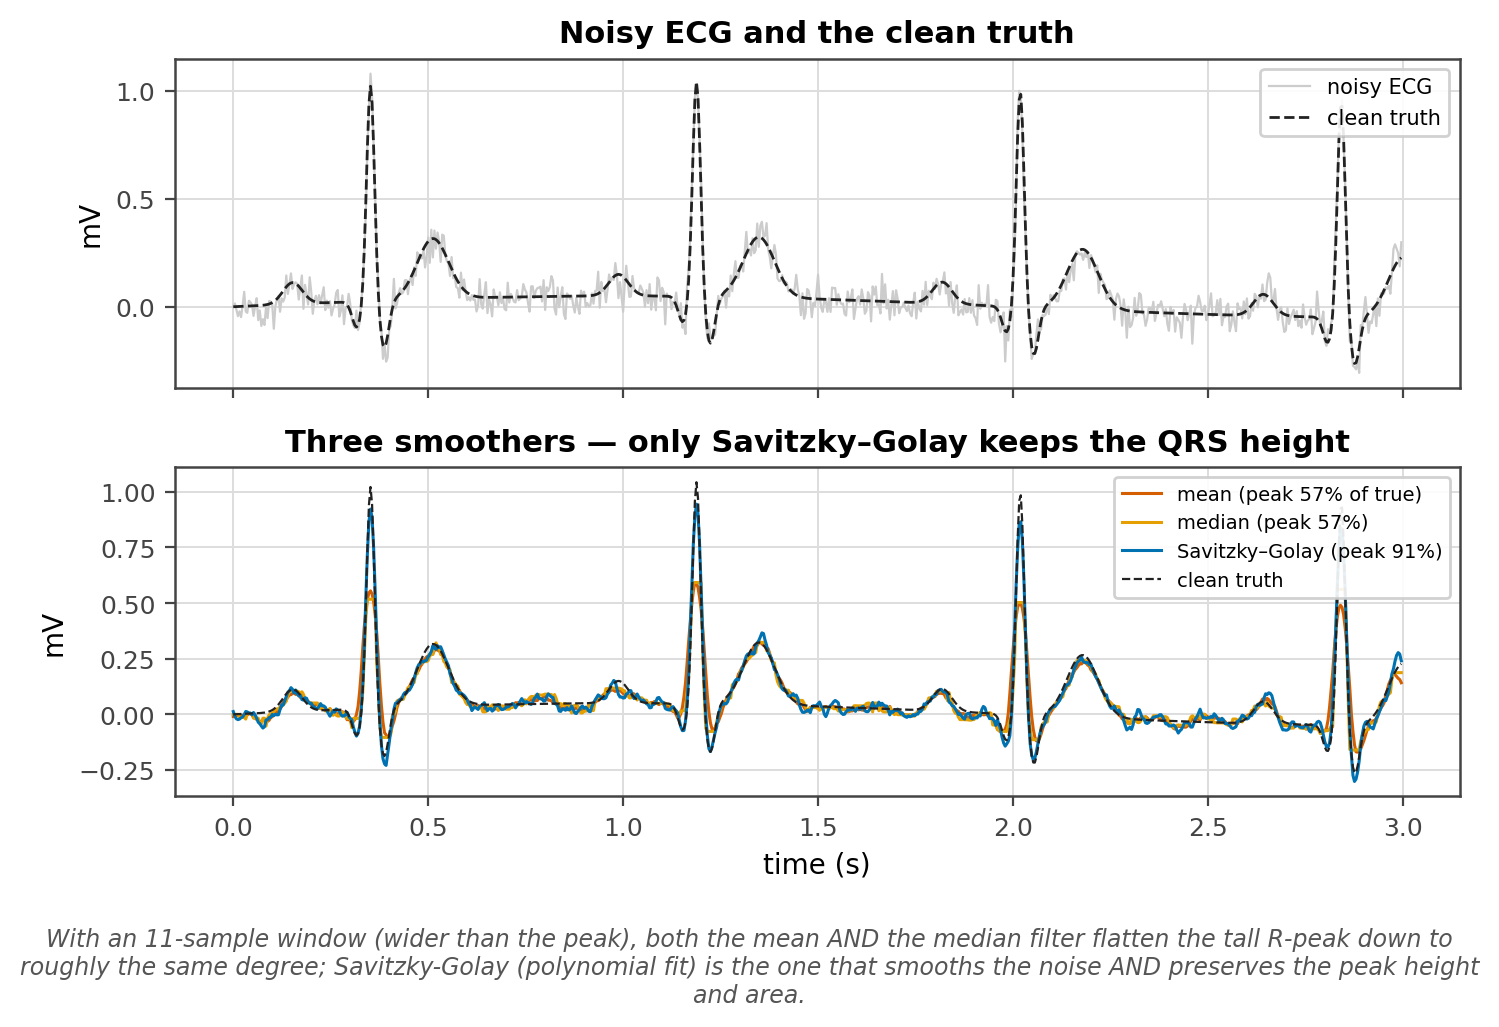

In [8]:
# Savitzky-Golay smooths broadband noise while preserving the QRS peak.
# At this window width (11 samples, wider than the peak itself) a plain
# median filter flattens the peak about as much as the mean does -- median's
# usual edge-preserving advantage needs a window narrower than the feature;
# only Savitzky-Golay's local polynomial fit keeps the peak height here.
from scipy.signal import savgol_filter, medfilt
t, x = bio.ecg(duration=3.0, fs=250, hr=72, noise=0.0)
fs = 250.0
r = bio.rng(7)
noisy = x + 0.05 * r.standard_normal(len(x))       # broadband noise
w = 11
mean_f = np.convolve(noisy, np.ones(w) / w, "same")
med_f = medfilt(noisy, w)
sg_f = savgol_filter(noisy, window_length=w, polyorder=3)
# peak-preservation number: recovered R-peak height vs the clean truth
ipk = int(np.argmax(x))
truth = x[ipk]
fig, ax = bs.newfig(w=7.4, h=4.6, nrows=2, ncols=1, sharex=True)
ax[0].plot(t, noisy, color=bs.C["lightgrey"], lw=0.8, label="noisy ECG")
ax[0].plot(t, x, color=bs.C["black"], lw=1.0, ls="--", label="clean truth")
ax[0].set_ylabel("mV"); ax[0].set_title("Noisy ECG and the clean truth")
ax[0].legend(loc="upper right", fontsize=7.5)
for sig_, lab, c in [(mean_f, f"mean (peak {mean_f[ipk]/truth*100:.0f}% of true)", bs.C["red"]),
                     (med_f, f"median (peak {med_f[ipk]/truth*100:.0f}%)", bs.C["orange"]),
                     (sg_f, f"Savitzky–Golay (peak {sg_f[ipk]/truth*100:.0f}%)", bs.C["blue"])]:
    ax[1].plot(t, sig_, lw=1.1, color=c, label=lab)
ax[1].plot(t, x, color=bs.C["black"], lw=0.8, ls="--", label="clean truth")
ax[1].set_ylabel("mV"); ax[1].set_xlabel("time (s)")
ax[1].set_title("Three smoothers — only Savitzky–Golay keeps the QRS height")
ax[1].legend(loc="upper right", fontsize=7.0)
bs.takeaway(fig, "With an 11-sample window (wider than the peak), both the mean AND the median "
                 "filter flatten the tall R-peak down to roughly the same degree; "
                 "Savitzky-Golay (polynomial fit) is the one that smooths the noise AND preserves the peak height and area.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `butter`, `filtfilt`, `medfilt1`/`medfilt2`, `conv2`, `sos`.

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Clean salt-and-pepper on an image with mean vs median, then repeat on ECG spikes.

<details><summary>💡 Hint &amp; what you should see</summary>

**Median** filtering removes impulsive spikes without smearing edges; the mean filter smears the spike into its neighbours. The same non-linear trick works on ECG motion spikes.

</details>

**2.** Run the five Pan–Tompkins stages and mark the detected R-peaks.

<details><summary>💡 Hint &amp; what you should see</summary>

band-pass → derivative → square → moving-window integrate → threshold. Each stage progressively isolates the QRS from P/T waves, drift, and noise; the moving-window integrator turns it into one clean detection bump, and the marks should sit on the **R** spikes. This template reappears in CTG deceleration and EMG onset detection — learn it once, reuse it three ways.

</details>

In [9]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch09_figures.py`.*